In [1]:
import glob
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import numpy as np
from regions import Regions
from astropy.nddata import Cutout2D
import astropy.units as u
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from astropy.table import Table
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f1500w": "/orange/adamginsburg/jwst/w51/F1500W/pipeline/jw06151-o002_t001_miri_f1500w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}




#nrca_catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/basic_nrca_indivexp_photometry_tables_merged.fits')
#nrcb_catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/basic_nrcb_indivexp_photometry_tables_merged.fits')
#catalog_f140m_nrca = Table.read()
nrca_catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrca_indivexp_merged_dao_basic.fits')
nrcb_catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrcb_indivexp_merged_dao_basic.fits')
test_regions = Regions.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/f140m_refine_test.reg', format='crtf')
by_eye_sources = Regions.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/by_eye_star_f140m.reg', format='crtf')

ra_reg = []
dec_reg = []
for reg in by_eye_sources:
    ra_reg.append(reg.center.ra.deg)
    dec_reg.append(reg.center.dec.deg)
by_eye_skycoord = SkyCoord(ra=ra_reg*u.deg, dec=dec_reg*u.deg, frame='icrs')


(0.0, 5.0)

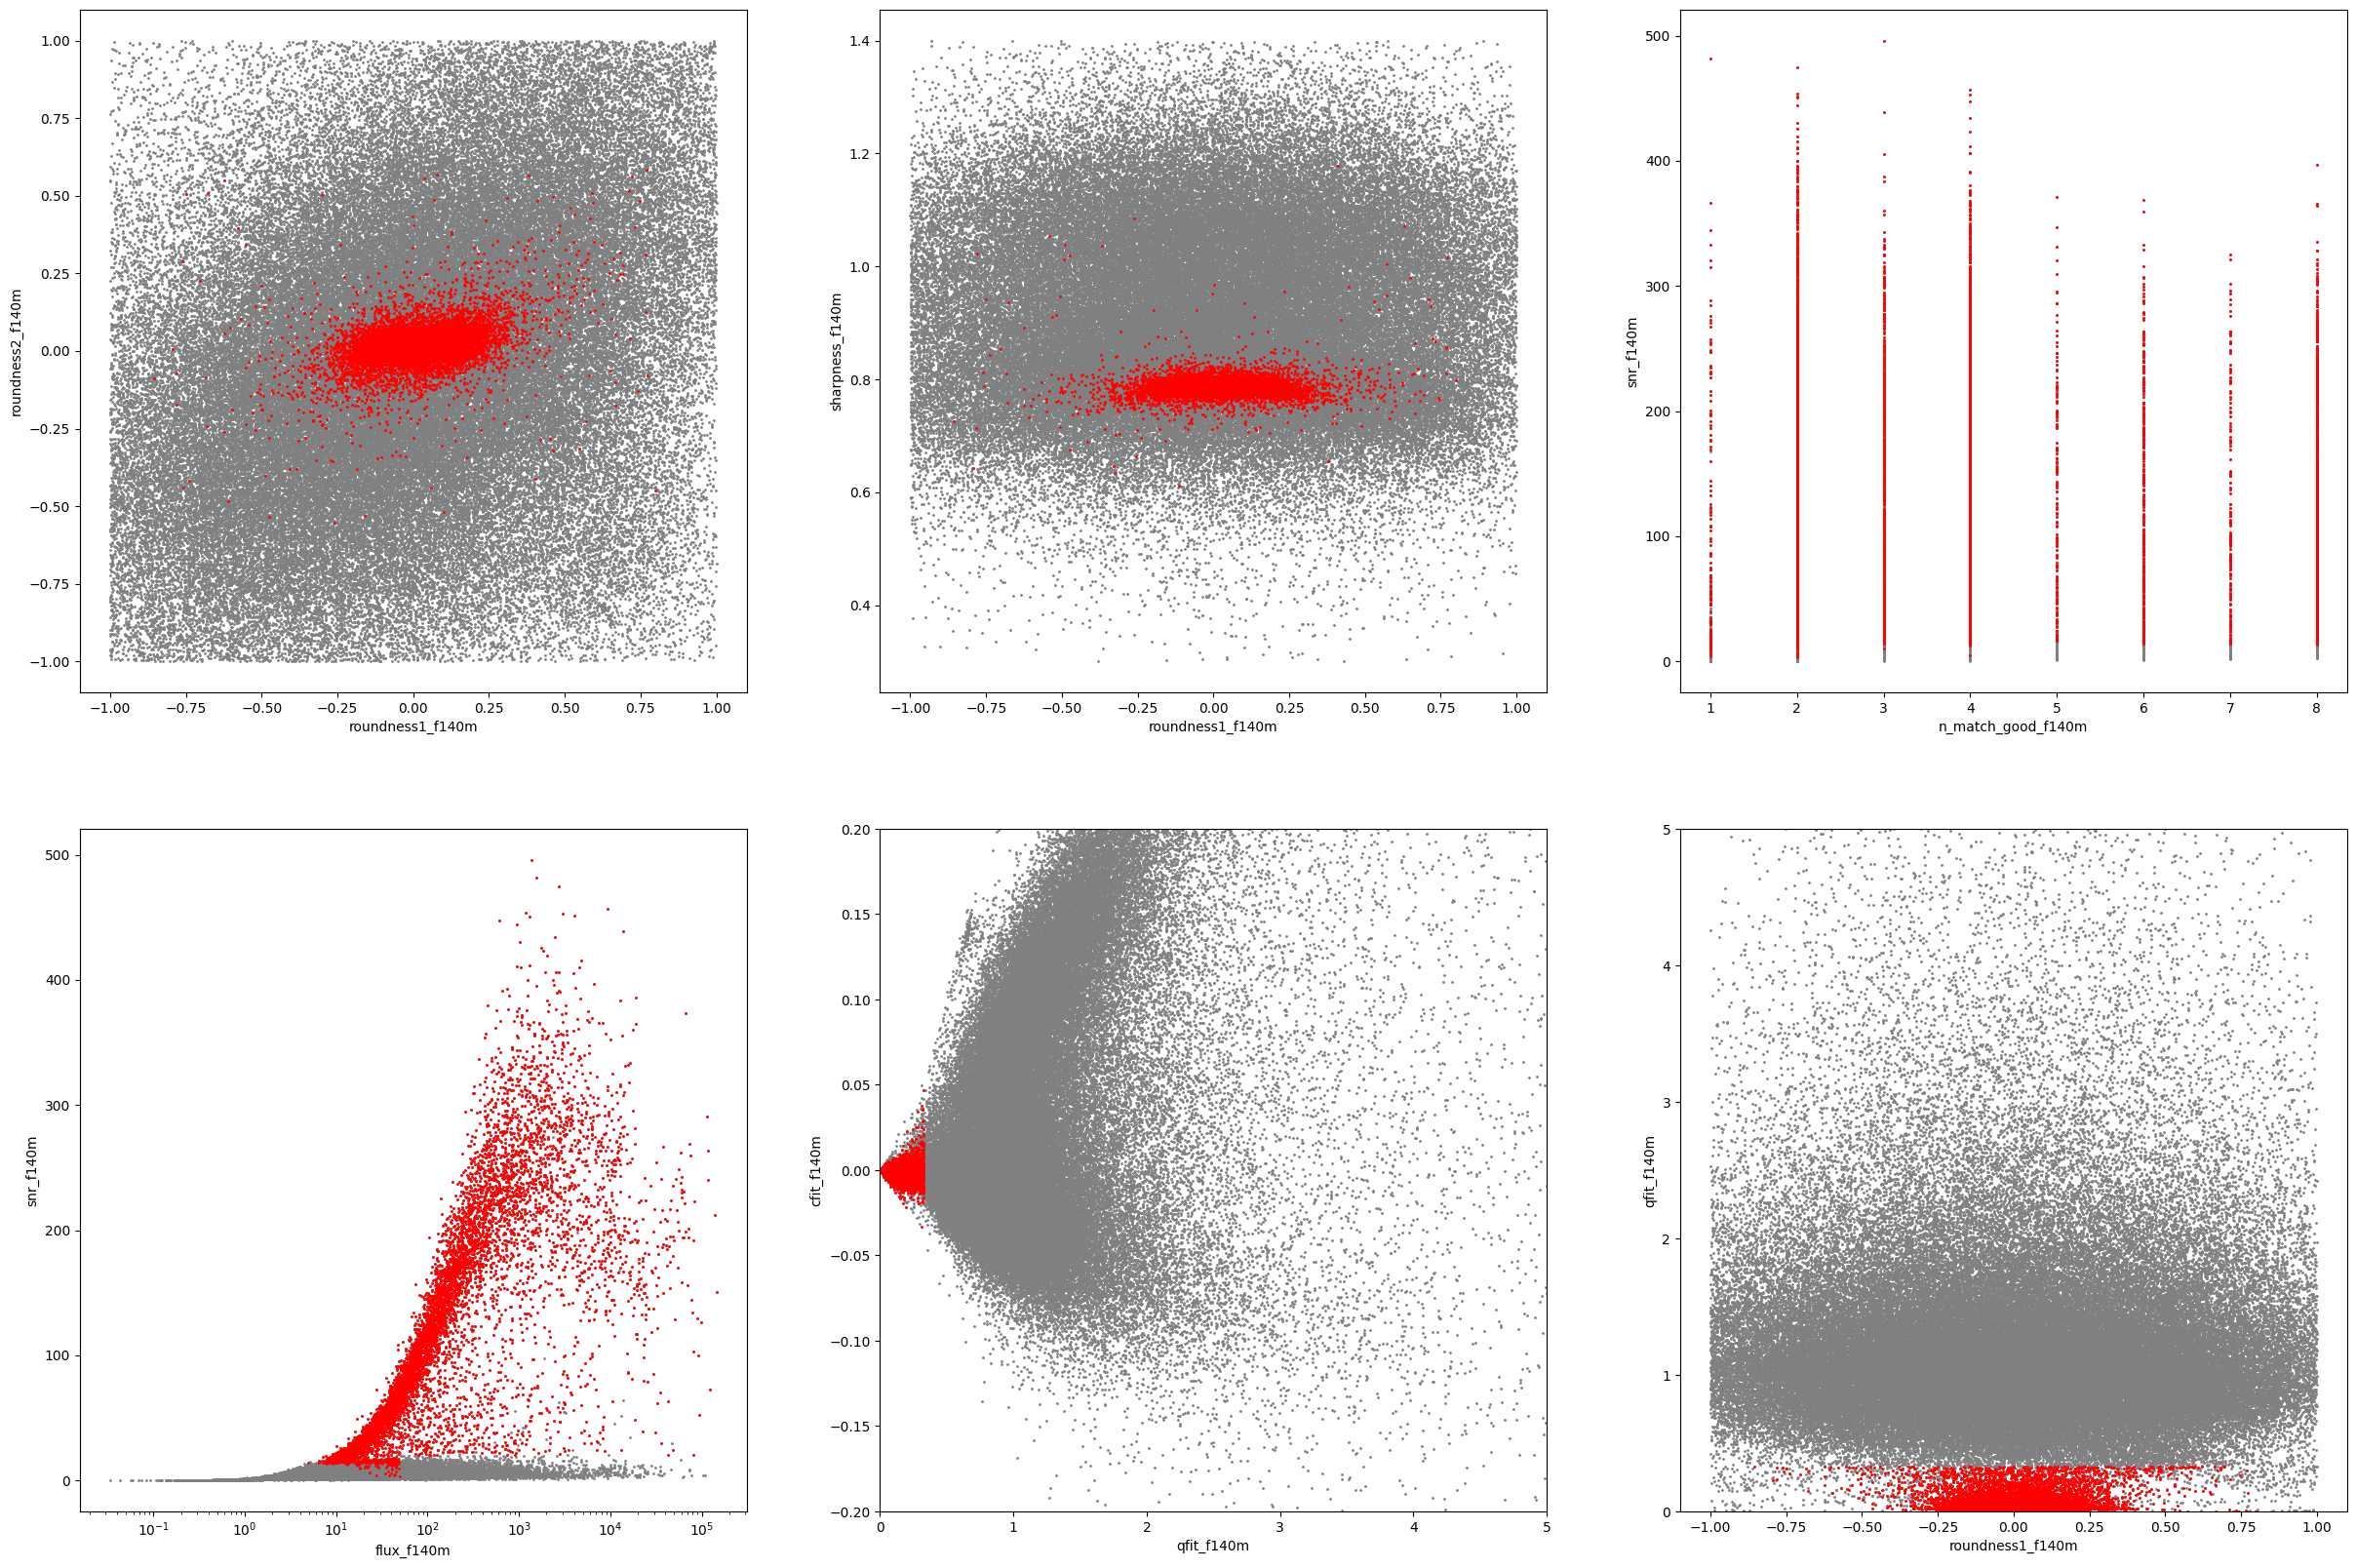

In [2]:
roundness1_f140m = nrca_catalog['roundness1']
roundness2_f140m = nrca_catalog['roundness2']
sharpness_f140m = nrca_catalog['sharpness']
flux_f140m = nrca_catalog['flux_fit']
fluxerr_f140m = nrca_catalog['flux_err']
snr_f140m = flux_f140m/fluxerr_f140m
qfit_f140m = nrca_catalog['qfit']
cfit_f140m = nrca_catalog['cfit']
skycoord = nrca_catalog['skycoord']
n_match_good_f140m = nrca_catalog['nmatch_good']

good_sources = ((roundness1_f140m < 0.8) & (roundness1_f140m > -0.9) & (roundness2_f140m < 0.6) & (roundness2_f140m > -0.6) & (sharpness_f140m < 1.2) & (sharpness_f140m>0.25) 
& (snr_f140m > 3) & (qfit_f140m < 0.33) & (cfit_f140m < 0.2) & (cfit_f140m > -0.2) & ~((snr_f140m < 20) & (flux_f140m > 50)))


fig = plt.figure(figsize=(30,20))
ax1 = fig.add_subplot(231)
ax1.scatter(roundness1_f140m, roundness2_f140m, s=1, color='gray')
ax1.scatter(roundness1_f140m[good_sources], roundness2_f140m[good_sources], s=1, color='red')
ax1.set_xlabel('roundness1_f140m')
ax1.set_ylabel('roundness2_f140m')

ax2 = fig.add_subplot(232)
ax2.scatter(roundness1_f140m, sharpness_f140m, s=1, color='gray')
ax2.scatter(roundness1_f140m[good_sources], sharpness_f140m[good_sources], s=1, color='red')
ax2.set_xlabel('roundness1_f140m')
ax2.set_ylabel('sharpness_f140m')   

ax3 = fig.add_subplot(233)
ax3.scatter(n_match_good_f140m, snr_f140m, s=1, color='gray')
ax3.scatter(n_match_good_f140m[good_sources], snr_f140m[good_sources], s=1, color='red')
ax3.set_xlabel('n_match_good_f140m')
ax3.set_ylabel('snr_f140m')

ax4 = fig.add_subplot(234)
ax4.scatter(flux_f140m, snr_f140m, s=1, color='gray')
ax4.scatter(flux_f140m[good_sources], snr_f140m[good_sources], s=1, color='red')
ax4.set_xlabel('flux_f140m')
ax4.set_ylabel('snr_f140m') 
ax4.set_xscale('log')

ax5 = fig.add_subplot(235)
ax5.scatter(qfit_f140m, cfit_f140m, s=1, color='gray')
ax5.scatter(qfit_f140m[good_sources], cfit_f140m[good_sources], s=1, color='red')
ax5.set_xlabel('qfit_f140m')
ax5.set_ylabel('cfit_f140m')   
ax5.set_xlim(0,5)
ax5.set_ylim(-0.2, 0.2)

ax6 = fig.add_subplot(236)
ax6.scatter(roundness1_f140m, qfit_f140m, s=1, color='gray')
ax6.scatter(roundness1_f140m[good_sources], qfit_f140m[good_sources], s=1, color='red')
ax6.set_xlabel('roundness1_f140m')
ax6.set_ylabel('qfit_f140m')
ax6.set_ylim(0,5)




426 115640 426
[ 36681  36719  36427  36065  35958  35921  35951  35865  35924  36028
  35805  35642  39679  39674  36450  36196  36310  36329  36213  36435
  36664  36711  36696  36566  36499  36463  36401  36364  36319  36529
  35862  35826  35866  35978  36251  35982  35822  35782  35651  35628
  35583  35603  35570  35435  35352  35305  35208  35444  35516  35555
  34722  34711  34844  35051  34961  35065  35056  34953  34386  34771
  34896  34743  34906  34813  34897  34773  34150  34294  34207  34286
  34320  34525  34777  34684  34605  34415  34148  34099  34370  34378
  34529 112834 112879 112866 112800 112799 112779 112754 112723 112973
 112941  94631  94547  35253  35092  35485  35525  35422  35236  35437
  35407  35354 113039 113088  35174  35646 113072 113014  94881 113126
 113145 113189 113183 113132  35611  35594 113249 113369 113421 113396
 113471 113439 113492 113510 113515  96496  95755 113366 113463  95943
 113241  89137  89008  88964  88861  88749  88610  88666  8860

Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


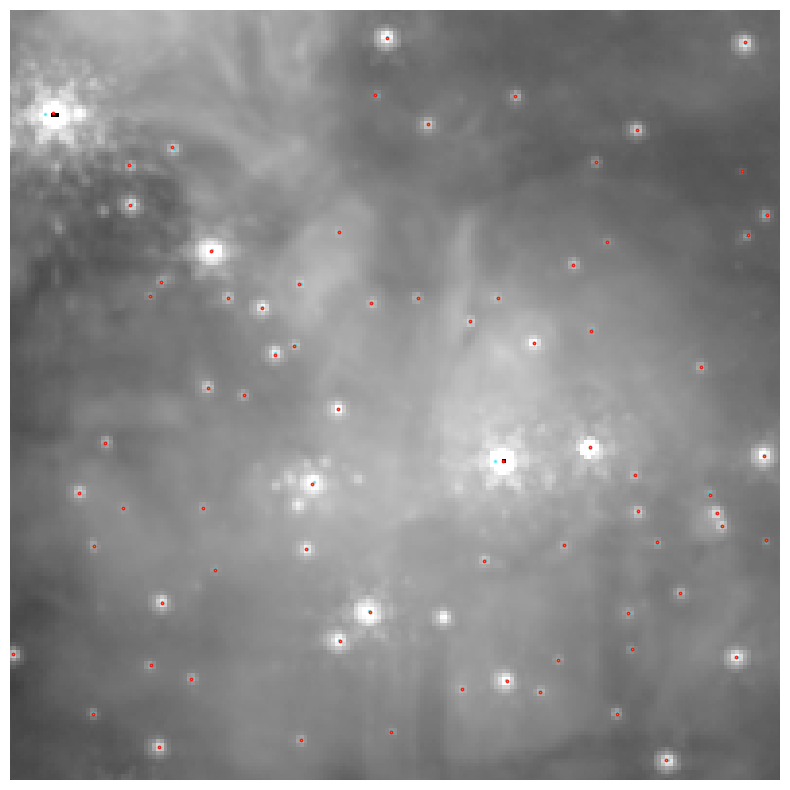

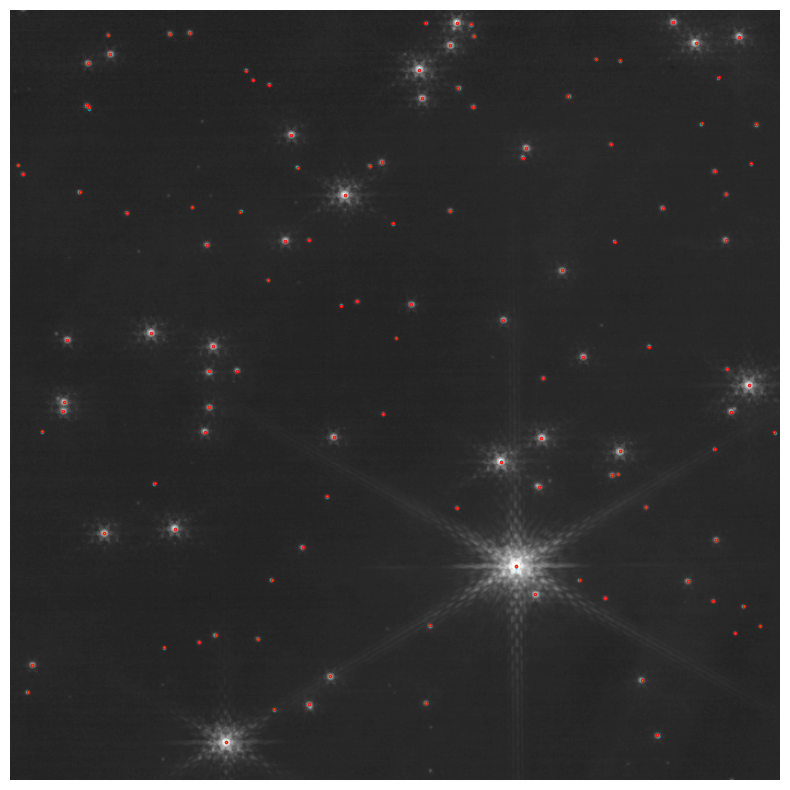

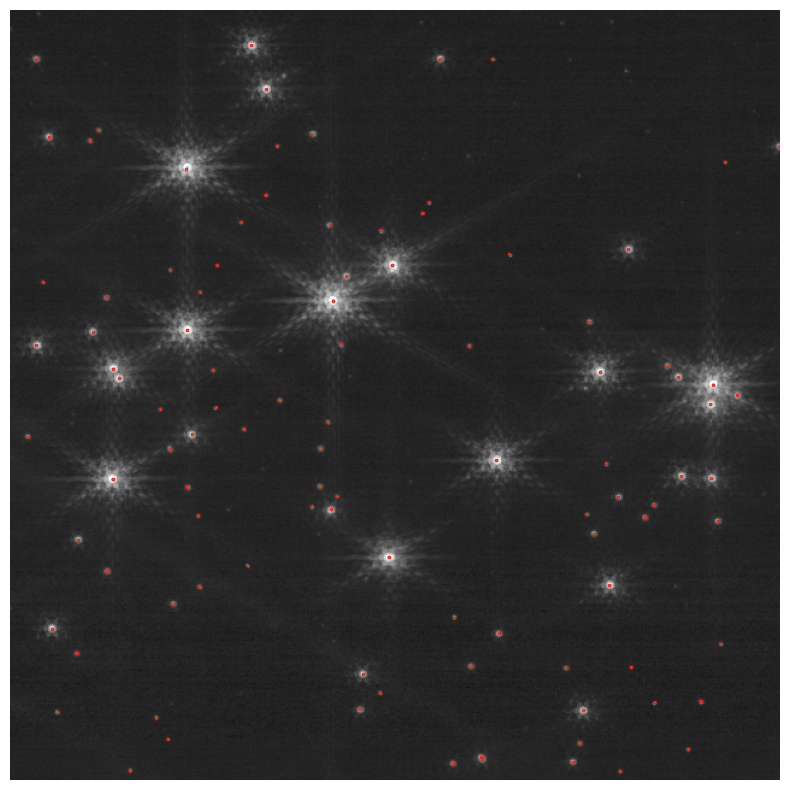

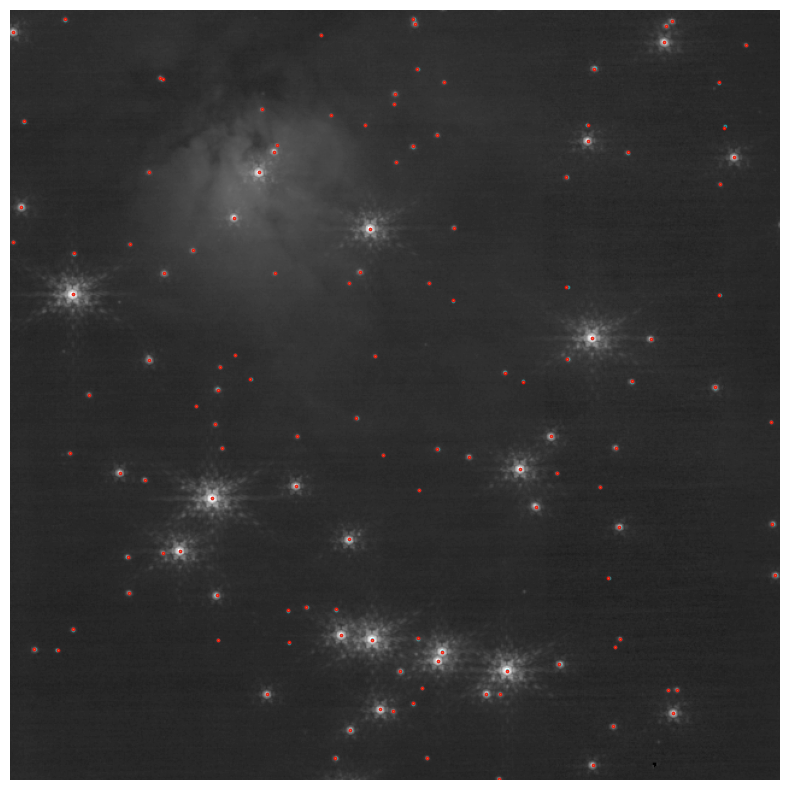

In [3]:
idx, d2d, d3d = by_eye_skycoord.match_to_catalog_sky(nrca_catalog['skycoord'])
print(len(idx), len(nrca_catalog['skycoord']), len(by_eye_skycoord))
print(idx)
matched = d2d < 0.1*u.arcsec
print(f'{len(matched==True)} sources out of {len(matched)} matched within 0.1 arcsec')
matched_skycoord = nrca_catalog['skycoord'][idx[matched]]
contains_arr = np.zeros(len(nrca_catalog['skycoord']), dtype=bool)
for reg in test_regions:
    filename = image_filenames['f140m']
    hdu = fits.open(filename)
    data = hdu[1].data if len(hdu) > 1 else hdu[0].data
    wcs = WCS(hdu[1].header if len(hdu) > 1 else hdu[0].header)
    cutout = Cutout2D(data, reg.center, (reg.height, reg.width), wcs=wcs)
    norm = simple_norm(data, 'log', percent=99.95)
    fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': cutout.wcs})
    ax.imshow(cutout.data, norm=norm, origin='lower', cmap='gray')
    skycoord_ref = nrca_catalog['skycoord']
    contains = reg.contains(skycoord_ref, wcs)
    contains_arr[contains] = True
    #convert skycoordinates to pixel coordinates in the cutout
    pixcoords_matched = cutout.wcs.world_to_pixel(matched_skycoord)
    pixcoords_by_eye_skycoord = cutout.wcs.world_to_pixel(by_eye_skycoord[matched])


    ra = pixcoords_matched[0]
    dec = pixcoords_matched[1]
    ax.scatter(ra, dec, s=3, edgecolor='cyan', alpha=0.4)
    ra = pixcoords_by_eye_skycoord[0]
    dec = pixcoords_by_eye_skycoord[1]
    ax.scatter(ra, dec, s=3, edgecolor='red', alpha=0.8)
    #ra = pixcoords[0][index] --- IGNORE
    ax.axis('off')
    ax.set_xlim(cutout.xmin_cutout, cutout.xmax_cutout)
    ax.set_ylim(cutout.ymin_cutout, cutout.ymax_cutout)

(0.0, 5.0)

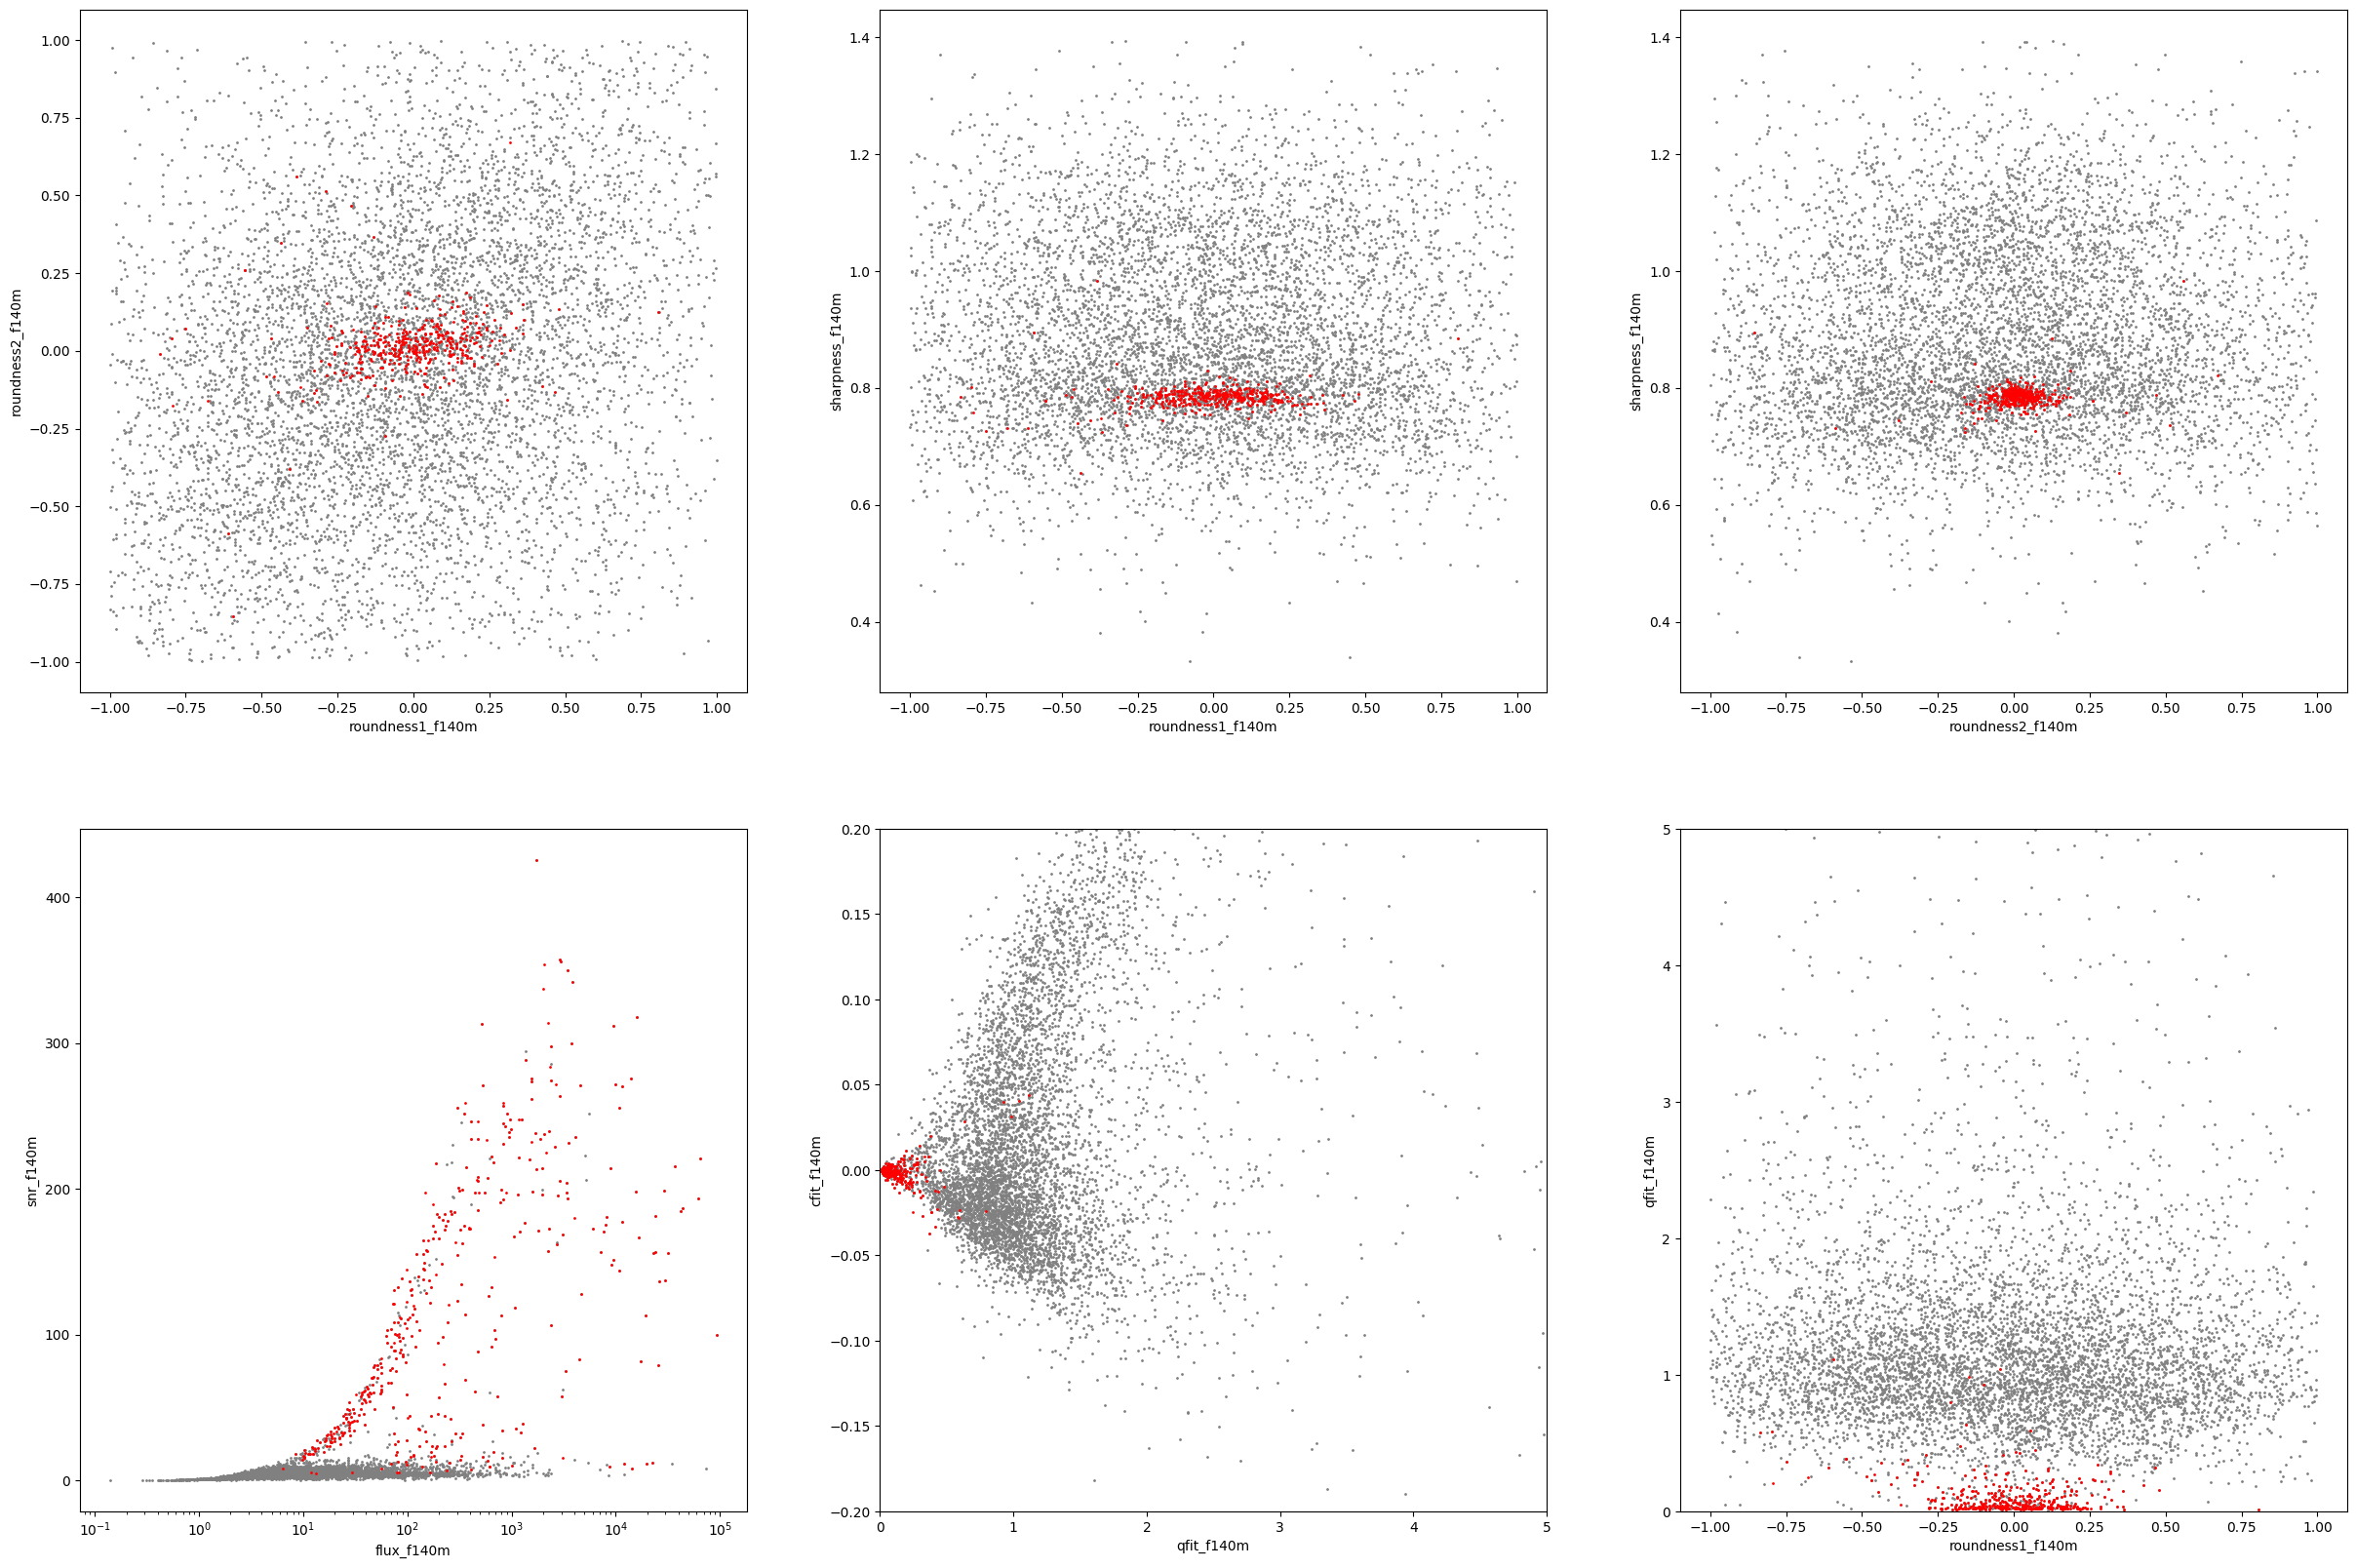

In [4]:
fig = plt.figure(figsize=(30,20))
ax1 = fig.add_subplot(231)
ax1.scatter(roundness1_f140m[contains_arr], roundness2_f140m[contains_arr], s=1, color='gray')
ax1.scatter(roundness1_f140m[idx], roundness2_f140m[idx], s=1, color='red')
ax1.set_xlabel('roundness1_f140m')
ax1.set_ylabel('roundness2_f140m')

ax2 = fig.add_subplot(232)
ax2.scatter(roundness1_f140m[contains_arr], sharpness_f140m[contains_arr], s=1, color='gray')
ax2.scatter(roundness1_f140m[idx], sharpness_f140m[idx], s=1, color='red')
ax2.set_xlabel('roundness1_f140m')
ax2.set_ylabel('sharpness_f140m')   

ax3 = fig.add_subplot(233)
ax3.scatter(roundness2_f140m[contains_arr], sharpness_f140m[contains_arr], s=1, color='gray')
ax3.scatter(roundness2_f140m[idx], sharpness_f140m[idx], s=1, color='red')
ax3.set_xlabel('roundness2_f140m')
ax3.set_ylabel('sharpness_f140m')   

ax4 = fig.add_subplot(234)
ax4.scatter(flux_f140m[contains_arr], snr_f140m[contains_arr], s=1, color='gray')
ax4.scatter(flux_f140m[idx], snr_f140m[idx], s=1, color='red')
ax4.set_xlabel('flux_f140m')
ax4.set_ylabel('snr_f140m') 
ax4.set_xscale('log')

ax5 = fig.add_subplot(235)
ax5.scatter(qfit_f140m[contains_arr], cfit_f140m[contains_arr], s=1, color='gray')
ax5.scatter(qfit_f140m[idx], cfit_f140m[idx], s=1, color='red')
ax5.set_xlabel('qfit_f140m')
ax5.set_ylabel('cfit_f140m')   
ax5.set_xlim(0,5)
ax5.set_ylim(-0.2, 0.2)

ax6 = fig.add_subplot(236)
ax6.scatter(roundness1_f140m[contains_arr], qfit_f140m[contains_arr], s=1, color='gray')
ax6.scatter(roundness1_f140m[idx], qfit_f140m[idx], s=1, color='red')
ax6.set_xlabel('roundness1_f140m')
ax6.set_ylabel('qfit_f140m')
ax6.set_ylim(0,5)


(0.0, 5.0)

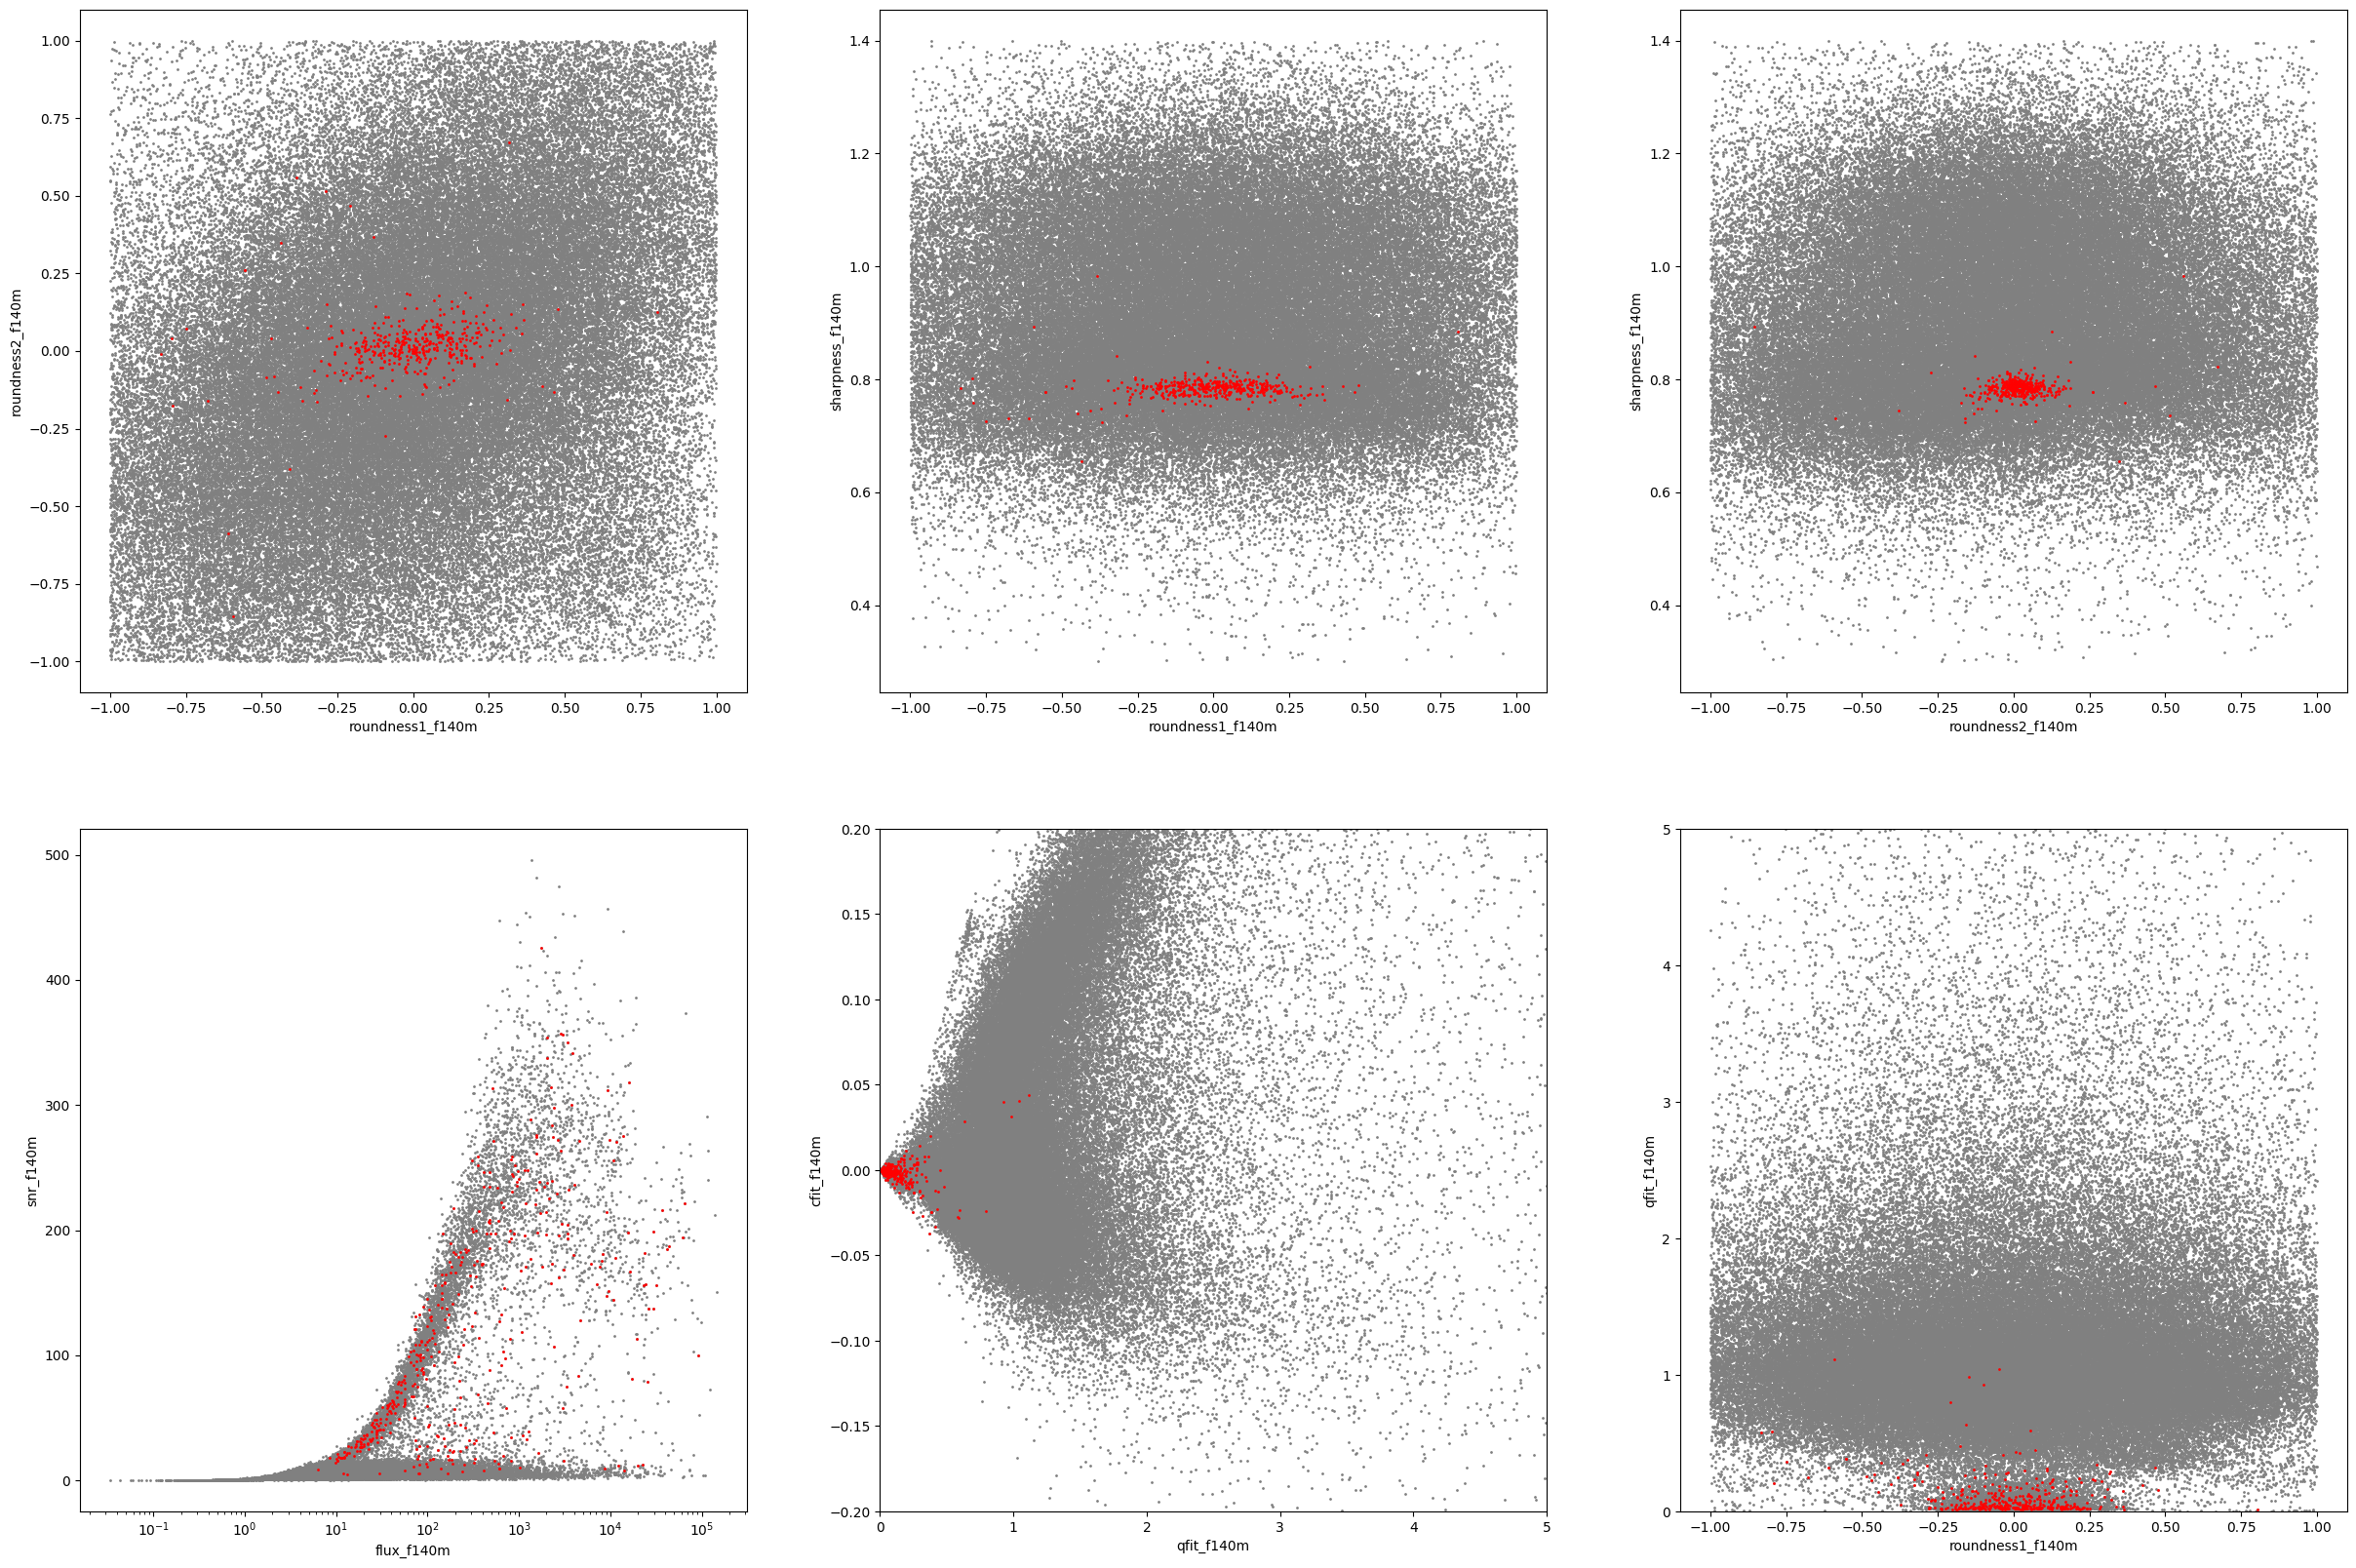

In [5]:
fig = plt.figure(figsize=(30,20))
ax1 = fig.add_subplot(231)
ax1.scatter(roundness1_f140m, roundness2_f140m, s=1, color='gray')
ax1.scatter(roundness1_f140m[idx], roundness2_f140m[idx], s=1, color='red')
ax1.set_xlabel('roundness1_f140m')
ax1.set_ylabel('roundness2_f140m')

ax2 = fig.add_subplot(232)
ax2.scatter(roundness1_f140m, sharpness_f140m, s=1, color='gray')
ax2.scatter(roundness1_f140m[idx], sharpness_f140m[idx], s=1, color='red')
ax2.set_xlabel('roundness1_f140m')
ax2.set_ylabel('sharpness_f140m')   

ax3 = fig.add_subplot(233)
ax3.scatter(roundness2_f140m, sharpness_f140m, s=1, color='gray')
ax3.scatter(roundness2_f140m[idx], sharpness_f140m[idx], s=1, color='red')
ax3.set_xlabel('roundness2_f140m')
ax3.set_ylabel('sharpness_f140m')   

ax4 = fig.add_subplot(234)
ax4.scatter(flux_f140m, snr_f140m, s=1, color='gray')
ax4.scatter(flux_f140m[idx], snr_f140m[idx], s=1, color='red')
ax4.set_xlabel('flux_f140m')
ax4.set_ylabel('snr_f140m') 
ax4.set_xscale('log')

ax5 = fig.add_subplot(235)
ax5.scatter(qfit_f140m, cfit_f140m, s=1, color='gray')
ax5.scatter(qfit_f140m[idx], cfit_f140m[idx], s=1, color='red')
ax5.set_xlabel('qfit_f140m')
ax5.set_ylabel('cfit_f140m')   
ax5.set_xlim(0,5)
ax5.set_ylim(-0.2, 0.2)

ax6 = fig.add_subplot(236)
ax6.scatter(roundness1_f140m, qfit_f140m, s=1, color='gray')
ax6.scatter(roundness1_f140m[idx], qfit_f140m[idx], s=1, color='red')
ax6.set_xlabel('roundness1_f140m')
ax6.set_ylabel('qfit_f140m')
ax6.set_ylim(0,5)

Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


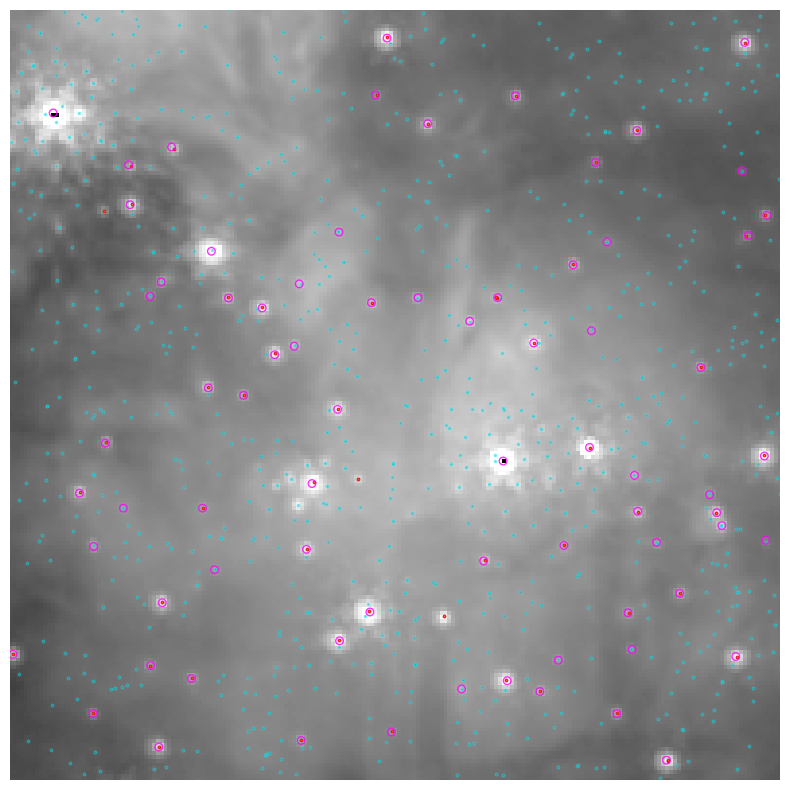

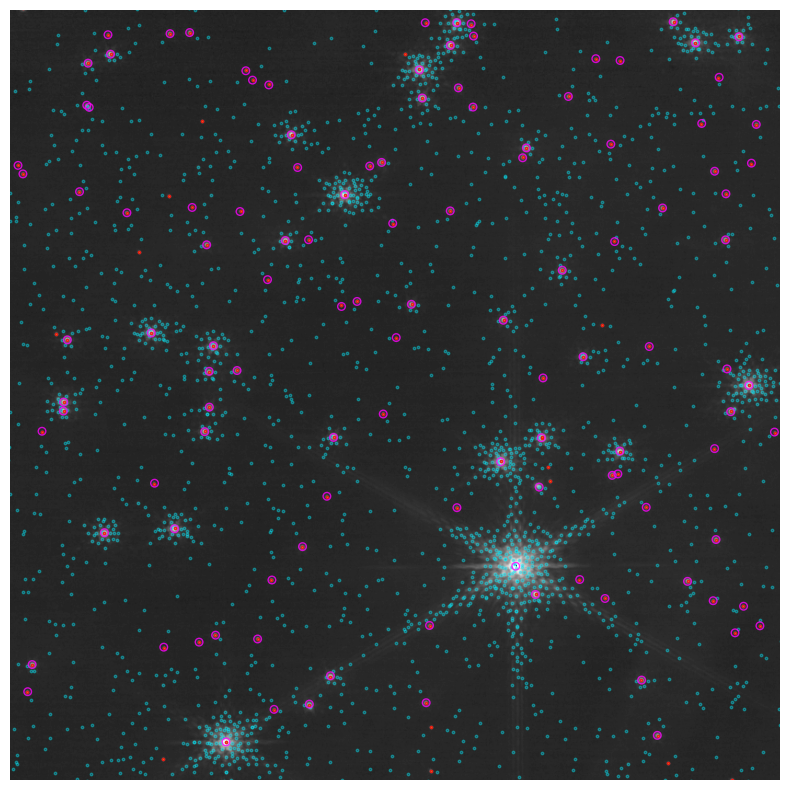

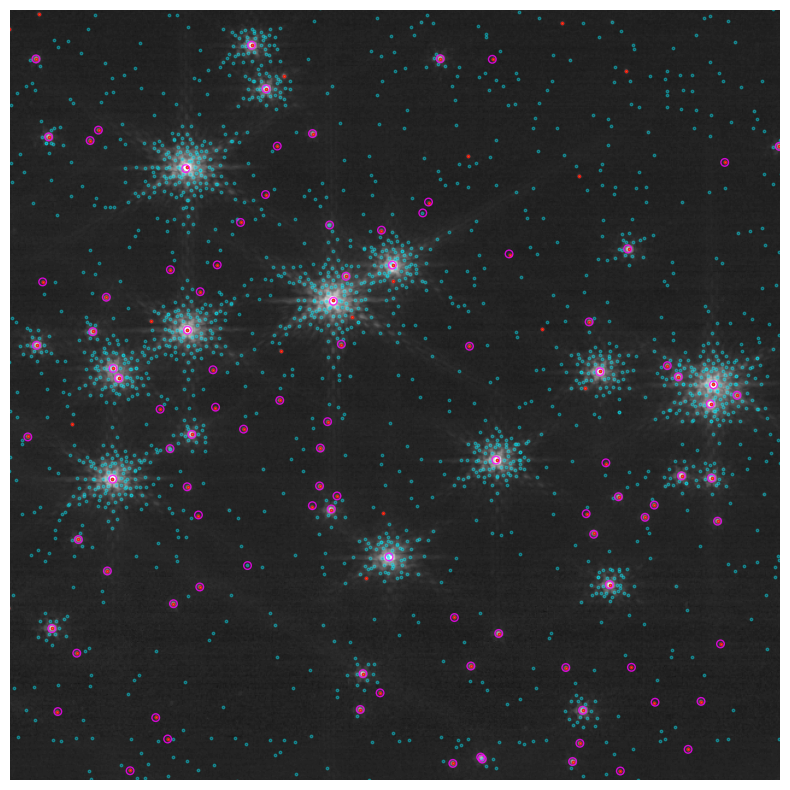

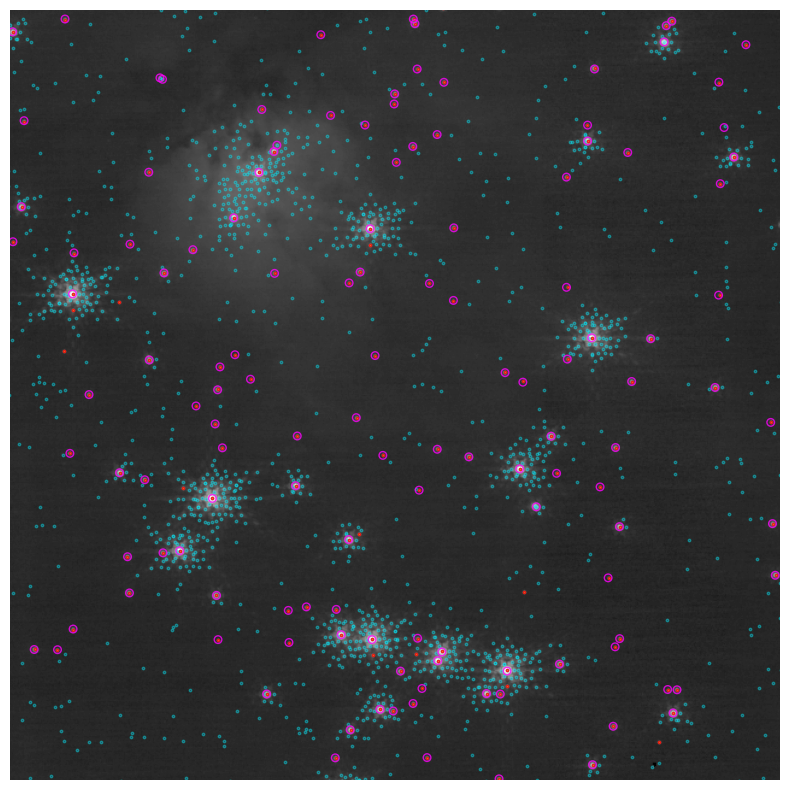

In [6]:





for reg in test_regions:
    filename = image_filenames['f140m']
    hdu = fits.open(filename)
    data = hdu[1].data if len(hdu) > 1 else hdu[0].data
    wcs = WCS(hdu[1].header if len(hdu) > 1 else hdu[0].header)
    cutout = Cutout2D(data, reg.center, (reg.height, reg.width), wcs=wcs)
    norm = simple_norm(data, 'log', percent=99.95)
    fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': cutout.wcs})
    ax.imshow(cutout.data, norm=norm, origin='lower', cmap='gray')
    skycoord_ref = nrca_catalog['skycoord']
    #convert skycoordinates to pixel coordinates in the cutout
    pixcoords = cutout.wcs.world_to_pixel(skycoord_ref)
    pixcoords_by_eye_skycoord = cutout.wcs.world_to_pixel(by_eye_skycoord)
  
    ra = pixcoords[0]
    dec = pixcoords[1]
    ax.scatter(ra, dec, s=3, edgecolor='cyan', alpha=0.4)
    ra = pixcoords[0][good_sources]
    dec = pixcoords[1][good_sources]
    ax.scatter(ra, dec, s=3, edgecolor='red', alpha=0.8)

    ra_by_eye = pixcoords_by_eye_skycoord[0]
    dec_by_eye = pixcoords_by_eye_skycoord[1]
    ax.scatter(ra_by_eye, dec_by_eye, s=30, edgecolor='magenta', facecolor='none', alpha=0.8)
    #ra = pixcoords[0][index] --- IGNORE
    ax.axis('off')
    ax.set_xlim(cutout.xmin_cutout, cutout.xmax_cutout)
    ax.set_ylim(cutout.ymin_cutout, cutout.ymax_cutout)


In [7]:
# found a group of sources that are close together within the pixel size


def remove_close_duplicates(nrca_catalog, pixel_scale=0.063*u.arcsec):
    """
    Remove sources from the catalog that are within 1 pixel of each other,
    keeping only the source with the lowest qfit value in each group.

    Parameters:
    -----------
    nrca_catalog : astropy Table
        The input catalog with 'skycoord' and 'qfit' columns.
    pixel_scale : astropy Quantity
        The pixel scale in arcseconds (default is 0.063 arcsec).

    Returns:
    --------
    filtered_catalog : astropy Table
        The catalog after removing close duplicates.
    """
    import numpy as np
    from astropy.coordinates import SkyCoord
    from astropy import units as u
    # Get sky coordinates
    skycoord = nrca_catalog['skycoord']
    qfit = nrca_catalog['qfit']

    # Find all pairs within 1 pixel
    idx1, idx2, sep2d, _ = skycoord.search_around_sky(skycoord, pixel_scale)

    # Remove self-matches
    mask = idx1 != idx2
    idx1 = idx1[mask]
    idx2 = idx2[mask]
    sep2d = sep2d[mask]

    # Grouping: for each star, find all neighbors within 1 pixel
    from collections import defaultdict
    neighbor_groups = defaultdict(set)
    for i1, i2 in zip(idx1, idx2):
        neighbor_groups[i1].add(i2)
        neighbor_groups[i2].add(i1)  # ensure symmetry

    # Find connected groups (clusters) using union-find
    parent = np.arange(len(skycoord))
    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i
    def union(i, j):
        pi, pj = find(i), find(j)
        if pi != pj:
            parent[pi] = pj
    for i1, i2 in zip(idx1, idx2):
        union(i1, i2)

    # Assign group ids
    group_ids = np.array([find(i) for i in range(len(skycoord))])

    # For each group, keep only the source with the lowest qfit
    unique_groups = np.unique(group_ids)
    keep_mask = np.zeros(len(skycoord), dtype=bool)
    for group in unique_groups:
        members = np.where(group_ids == group)[0]
        if len(members) == 1:
            keep_mask[members[0]] = True
        else:
            best = members[np.argmin(qfit[members])]
            keep_mask[best] = True
    print(f"Kept {np.sum(keep_mask)} out of {len(nrca_catalog)} sources after removing close duplicates.")

    return keep_mask




In [8]:
keep_mask_nrca = remove_close_duplicates(nrca_catalog, pixel_scale=0.031*u.arcsec)
keep_mask_nrcb = remove_close_duplicates(nrcb_catalog, pixel_scale=0.031*u.arcsec)

Kept 113805 out of 115640 sources after removing close duplicates.
Kept 107937 out of 109853 sources after removing close duplicates.


In [9]:
new_nrca_catalog = nrca_catalog[good_sources & keep_mask_nrca]
new_nrca_catalog.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrca_indivexp_merged_dao_refined.fits', overwrite=True)

In [10]:


good_sources_nrcb = ((nrcb_catalog['roundness1'] < 0.8) & (nrcb_catalog['roundness1'] > -0.9) & (nrcb_catalog['roundness2'] < 0.6) & (nrcb_catalog['roundness2'] > -0.6) & (nrcb_catalog['sharpness'] < 1.2) & (nrcb_catalog['sharpness']>0.25) 
& (nrcb_catalog['flux_fit']/nrcb_catalog['flux_err'] > 3) & (nrcb_catalog['qfit'] < 0.33) & (nrcb_catalog['cfit'] < 0.2) & (nrcb_catalog['cfit'] > -0.2) & ~((nrcb_catalog['flux_fit']/nrcb_catalog['flux_err'] < 20) & (nrcb_catalog['flux_fit'] > 50)) & (keep_mask_nrcb))
new_nrcb_catalog = nrcb_catalog[good_sources_nrcb]
new_nrcb_catalog.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrcb_indivexp_merged_dao_refined.fits', overwrite=True)